## For this task I will be using the "Bike Sharing" dataset from University of Porto, Portugal.

### Author's dataset description:
* Bike-sharing rental process is highly correlated to the environmental and seasonal settings.
* For instance, weather conditions, precipitation, day of week, season, hour of the day, etc. can affect the rental behaviors.
* The core data set is related to the two-year historical log corresponding to years 2011 and 2012 from Capital Bikeshare system, Washington D.C., USA which is  publicly available in http://capitalbikeshare.com/system-data.
* We aggregated the data on two hourly and daily basis and then  extracted and added the corresponding weather and seasonal information. Weather information are extracted from http://www.freemeteo.com.

### Dataset characteristics:
Both hour.csv (17379 total hours) and day.csv (731 total days) have the following fields, except "hr" which is not available in day.csv
* instant: record index
* dteday : date
* season : season (1:springer, 2:summer, 3:fall, 4:winter)
* yr : year (0: 2011, 1:2012)
* mnth : month ( 1 to 12)
* hr : hour (0 to 23)
* holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
* weekday : day of the week
* workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
* weathersit :
  * 1: Clear, Few clouds, Partly cloudy, Partly cloudy
  * 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  * 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  * 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* p : Normalized temperature in Celsius. The values are divided to 41 (max)
* mp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
* : Normalized humidity. The values are divided to 100 (max)
* dspeed: Normalized wind speed. The values are divided to 67 (max)
* ual: count of casual users
* istered: count of registered users
* : count of total rental bikes including both casual and registered

## Task:
* to do:
* Preparing the data.
* Cleaning the data.
* Normalizing, scaling the data.
* Calculating summary statistics to understand the underlying trends and distributions in the data.
* Visualizing the data using graphs, charts, and histograms to identify any patterns or anomalies in the data.
* Exploring correlations between variables.
* Selecting at least three machine learning algorithms.
* Training the models.
* Performing cross-validation.
* Performing grid search.
* Interpreting the results.

### First, let's import the libraries we will be using for this task.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

### Next, import the two datasets hours.csv and days.csv

In [103]:
df_hours = pd.read_csv('../../data/Bike Sharing/hour.csv')
df_days = pd.read_csv('../../data/Bike Sharing/day.csv')

In [104]:
df_hours.head(3)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


In [105]:
df_days.head(3)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349


#### Let's perform exploratory data analysis and check:
1. Are there any null values present?
2. Do any features datatypes need converting?
3. Are there any numeric variables that are highly correlated?

In [106]:
print("Null value count in Hours dataset:", df_hours.isnull().sum().sum())
print("Null value count in Days dataset:", df_days.isnull().sum().sum())

Null value count in Hours dataset: 0
Null value count in Days dataset: 0


In [107]:
df_hours.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


### We can see, that 'dteday' is practically useless, since the date has already been split for us into:
* Season (spring, summer, fall, winter)
* Year (0: 2011 or 1:2012)
* Month (1 to 12)
* Weekday (1-7)
* Working day (If not holiday or weekend = 1, else 0)
* Holiday (1 or 0)

Therefore, dropping this feature would simplify the model.

In [108]:
df_hours.drop("dteday", axis=1, inplace=True)
df_days.drop("dteday", axis=1, inplace=True)

### Also, 'instant' can be used as an index, which is provided by the dataset. It starts from 1 and ends at the N - the last sample.

In [109]:
df_hours.set_index('instant', inplace=True)
df_days.set_index('instant', inplace=True)

In [110]:
df_hours.tail(3)

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,,,,,,,,,,,,,,,
17377,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17378,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17379,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


#### We can see that 'registered' + 'casual' = 'cnt. Meaning, the two features 'registered' and 'casual' would be just a cheat code for our model. Since our task is to predict the 'cnt', let's drop these two features.

In [111]:
df_hours.drop('registered', axis=1, inplace=True)
df_days.drop('registered', axis=1, inplace=True)

df_days.drop('casual', axis=1, inplace=True)
df_hours.drop('casual', axis=1, inplace=True)

Great. Next we can take a look at 'weathersit'. The docs say, that:
- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog


For clarity we can rename this column to 'weather_severity' and make it 0 indexed.

Then, for example, if the weather is clear, sunny the 'weather_severity' is 0, while if there is a thunderstorm the 'weather_severity' is 3.

In [112]:
df_days["weather_severity"] = df_days["weathersit"] - 1
df_hours["weather_severity"] = df_hours["weathersit"] - 1

df_days.drop('weathersit', axis=1, inplace=True)
df_hours.drop('weathersit', axis=1, inplace=True)

Great! Next, let's generate a heatmap for each dataset and see which features have highest impact on 'cnt' feature, which we will predict.

In [113]:
def plot_heatmap(df, title="Correlation heatmap"):
    df_corr = df.corr()

    plt.figure(figsize = (8,8))
    plt.title(title)
    sns.heatmap(
        df_corr,
        annot=True,
        cmap='viridis',
        fmt=".1f",
        mask=np.triu(np.ones_like(df_corr, dtype=bool)),
        cbar=False)

    plt.show()

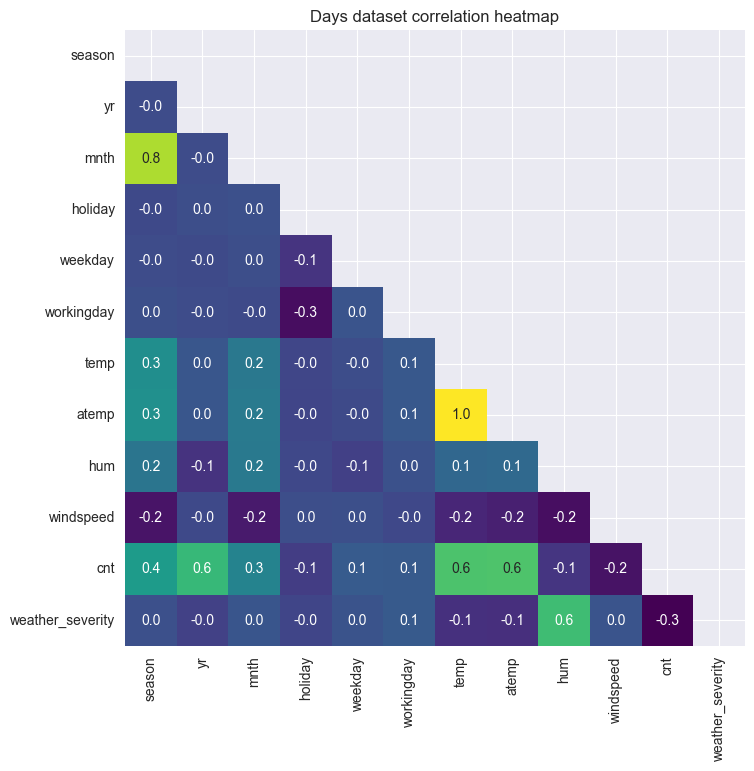

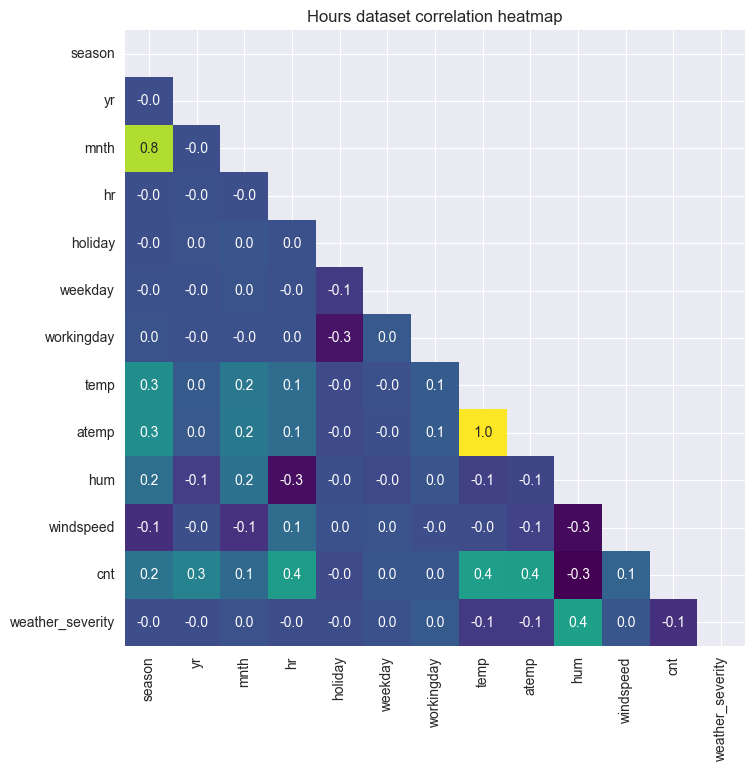

In [114]:
plot_heatmap(df_days, "Days dataset correlation heatmap")
plot_heatmap(df_hours, "Hours dataset correlation heatmap")

#### We can see, that 'temp' and 'atemp' are highly correlated with each other, which is bad, since it increases our models variance.

Let's leave only 'atemp', which is the normalized feeling temperature in Celsius and drop the 'temp' feature.

In [115]:
df_days.drop('temp', axis=1, inplace=True)
df_hours.drop('temp', axis=1, inplace=True)

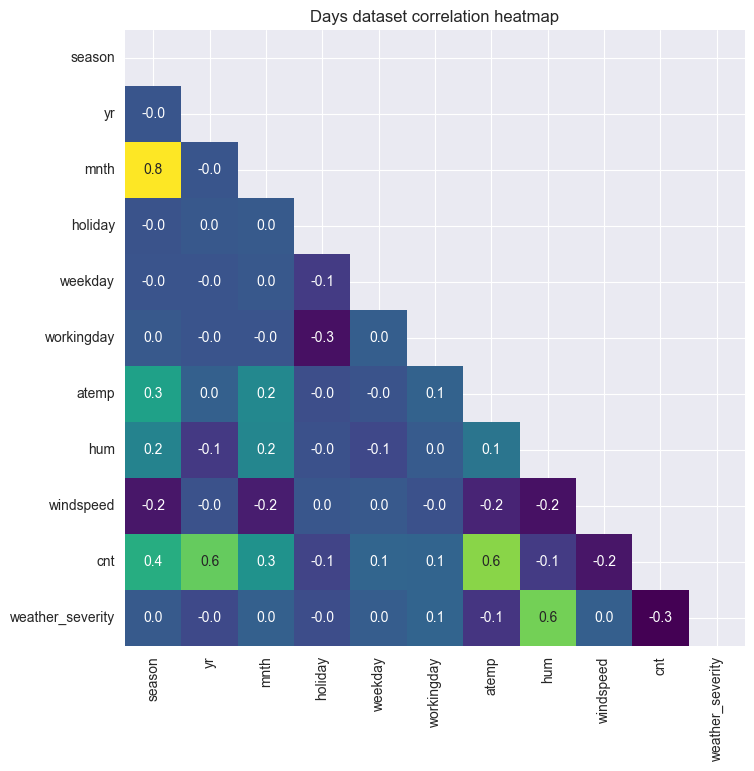

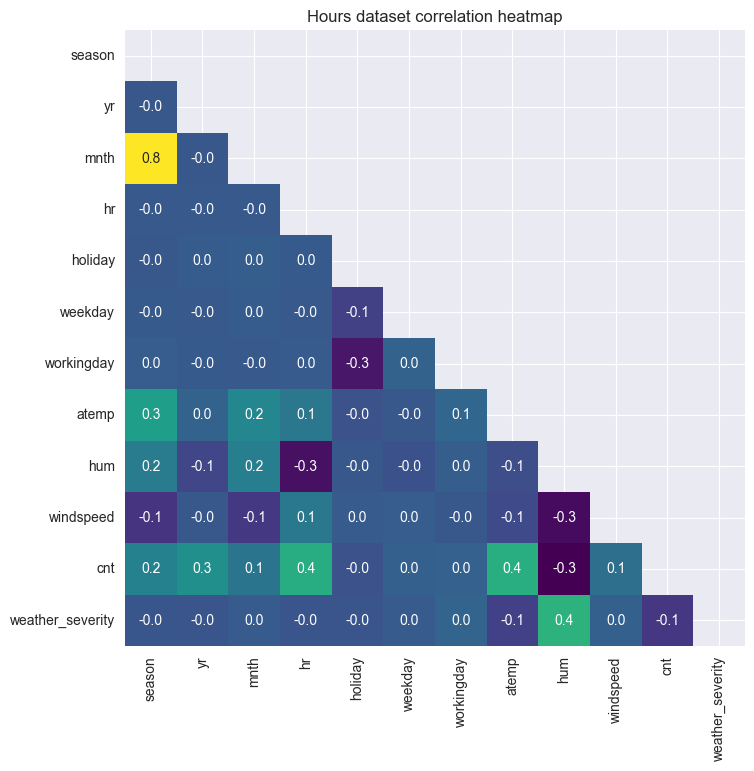

In [116]:
plot_heatmap(df_days, "Days dataset correlation heatmap")
plot_heatmap(df_hours, "Hours dataset correlation heatmap")

Great, we can see, that 'cnt' is influenced by each feature in a meaningful way.

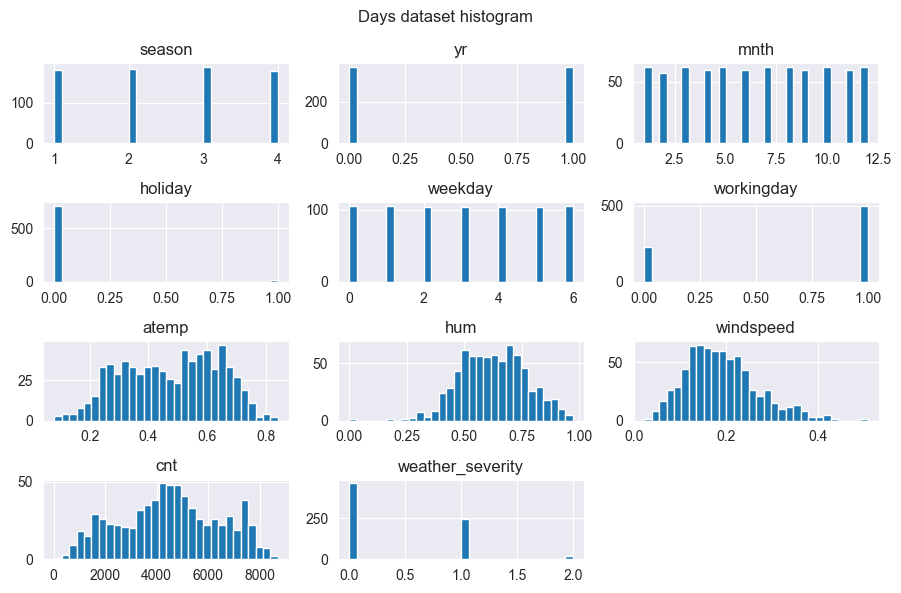

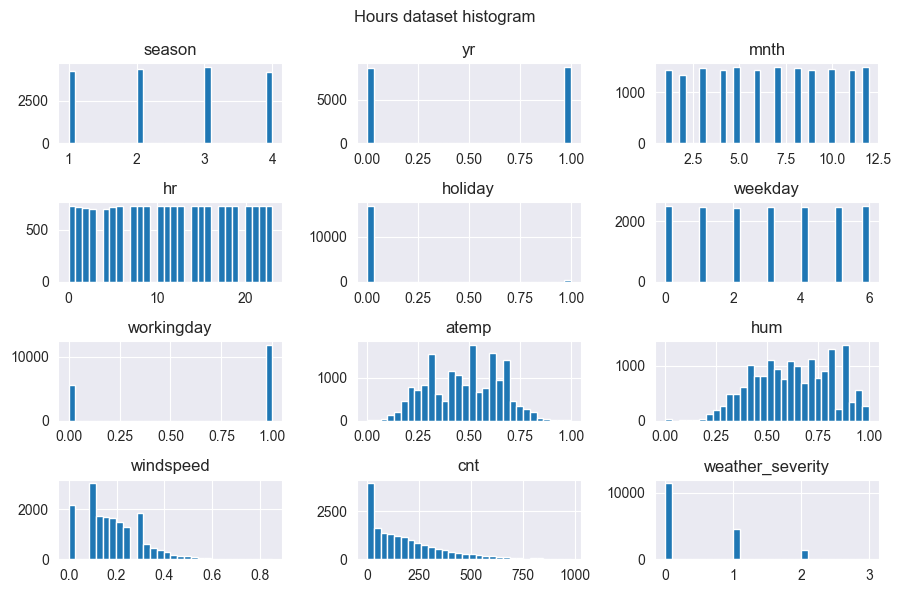

In [117]:
def plot_histogram(df, title="Histogram plot"):
    df.hist(figsize=(9,6), bins=30)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_histogram(df_days, "Days dataset histogram")
plot_histogram(df_hours, "Hours dataset histogram")


#### We can see, that for 'hours' dataset the 'cnt' feature, which we need to predict is right skewed.

Let's take a look at it closer.

Text(0.5, 1.0, "Original 'cnt'")

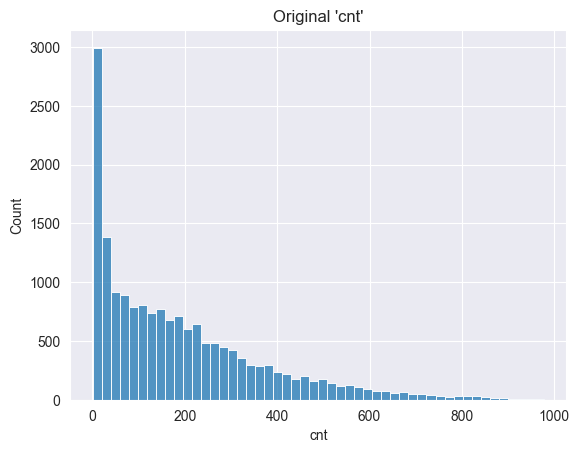

In [118]:
sns.histplot(df_hours['cnt'], bins=50)
plt.title("Original 'cnt'")

#### The fact, that it is right-skewed means, that:
 * It would hurt any linear regression model because it could **focus on fitting the smaller counts well, but then make large errors with the high counts.**

**Solutions for that are:**
* Train the model on a log(1 + cnt) target, instead of just 'cnt'. (+1 here because log0 is undefined)
* Make predictions and convert them back to original scale.

Note: Tested with Box-Cox aswell, however, the log method worked better.

In [119]:
print(df_hours['cnt'].skew())
print(df_days['cnt'].skew())

1.2774116037490573
-0.04735278011900183


Great. This means that we can use Box-Cox on the 'cnt' column.

#### Also, after taking a look at the data we can also replace:
* Mnth (month)
* Hr (hour) (only in hour dataset)
* Weekday

With **cyclical features using Sin and Cos**.

It is useful, because:
* Months 1 and 12 are close, while if we leave the features as is, they will be far away.
* Hour 23 and 0 are close aswell.

Therefore, let's replace these features by adding Cos and Sin versions of them:

In [120]:
def convert_to_cyclical(df, col, max_val):
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[f"{col}"] / max_val)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[f"{col}"] / max_val)

    df.drop(col, axis=1, inplace=True)

In [121]:
convert_to_cyclical(df_days, 'mnth', 12)
convert_to_cyclical(df_days, 'weekday', 7)

convert_to_cyclical(df_hours, 'mnth', 12)
convert_to_cyclical(df_hours, 'hr', 24)
convert_to_cyclical(df_hours, 'weekday', 7)

In [122]:
df_days.head(3)

,season,yr,holiday,workingday,atemp,hum,windspeed,cnt,weather_severity,mnth_sin,mnth_cos,weekday_sin,weekday_cos
instant,,,,,,,,,,,,,
1,1,0,0,0,0.363625,0.805833,0.160446,985,1,0.5,0.866025,-0.781831,0.62349
2,1,0,0,0,0.353739,0.696087,0.248539,801,1,0.5,0.866025,0.000000,1.00000
3,1,0,0,1,0.189405,0.437273,0.248309,1349,0,0.5,0.866025,0.781831,0.62349


In [123]:
df_hours.head(3)

,season,yr,holiday,workingday,atemp,hum,windspeed,cnt,weather_severity,mnth_sin,mnth_cos,hr_sin,hr_cos,weekday_sin,weekday_cos
instant,,,,,,,,,,,,,,,
1,1,0,0,0,0.2879,0.81,0.0,16,0,0.5,0.866025,0.000000,1.000000,-0.781831,0.62349
2,1,0,0,0,0.2727,0.80,0.0,40,0,0.5,0.866025,0.258819,0.965926,-0.781831,0.62349
3,1,0,0,0,0.2727,0.80,0.0,32,0,0.5,0.866025,0.500000,0.866025,-0.781831,0.62349


#### Great! We have prepared our data for training!

Let's now split it.

In [124]:
y_hours = df_hours['cnt']
X_hours = df_hours.drop('cnt', axis=1)

X_hour_train, X_hour_test, y_hour_train, y_hour_test = train_test_split(
    X_hours, y_hours, test_size=0.3, random_state=10
)

In [125]:
y_days = df_days['cnt']
X_days = df_days.drop('cnt', axis=1)

X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_days, y_days, test_size=0.3, random_state=10
)

#### Since we need to implement 3 models, I have chosen to implement:
1. **Linear Regression model** (using sin, cos method)
2. **Random Forest Regressor**
3. **XGBoost model**

Great. Now let's train the models and get the results!

### 1. Linear Regression - Lasso, Ridge, Elastic Net. Let's see which is best.

In [126]:
def predict(grid, X_test, use_log=False):
    preds = grid.predict(X_test)
    return np.expm1(preds) if use_log else preds

In [127]:
def build_and_tune(model, param_grid, preprocessor, X_train, y_train):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1)

    grid.fit(X_train, y_train)

    return grid

In [128]:
results = []

def collect_results(model_name, y_test, y_pred, results):
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': model_name,
        'MAE': round(mae, 3),
        'R^2': round(r2, 3)
    })

In [129]:
def train_compare_logreg_models(X_train, y_train, X_test, y_test, use_log=True, label=""):
    y_train_trans = np.log1p(y_train) if use_log else y_train

    categorical_features = ['season']
    numerical_features = X_train.columns.drop(categorical_features).tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

    lasso_params = {'regressor__alpha': np.logspace(-5, 2, 10)}
    ridge_params = {'regressor__alpha': np.logspace(-5, 2, 10)}
    elastic_params = {
        'regressor__alpha': np.logspace(-5, 2, 10),
        'regressor__l1_ratio': np.linspace(0.1, 1.0, 10)
    }

    lasso_grid = build_and_tune(Lasso(max_iter=10000), lasso_params, preprocessor, X_train, y_train_trans)
    ridge_grid = build_and_tune(Ridge(max_iter=10000), ridge_params, preprocessor, X_train, y_train_trans)
    elastic_grid = build_and_tune(ElasticNet(max_iter=10000), elastic_params, preprocessor, X_train, y_train_trans)

    lasso_pred = predict(lasso_grid, X_test, use_log)
    ridge_pred = predict(ridge_grid, X_test, use_log)
    elastic_pred = predict(elastic_grid, X_test, use_log)

    collect_results(f"Lasso ({label})", y_test, lasso_pred, results)
    collect_results(f"Ridge ({label})", y_test, ridge_pred, results)
    collect_results(f"ElasticNet ({label})", y_test, elastic_pred, results)

    print("Error metrics on test set:")
    print(f"Lasso      : MAE = {mean_absolute_error(y_test, lasso_pred):.3f}, R^2 = {r2_score(y_test, lasso_pred):.3f}")
    print(f"Ridge      : MAE = {mean_absolute_error(y_test, ridge_pred):.3f}, R^2 = {r2_score(y_test, ridge_pred):.3f}")
    print(f"ElasticNet : MAE = {mean_absolute_error(y_test, elastic_pred):.3f}, R^2 = {r2_score(y_test, elastic_pred):.3f}")

    print("\nBest hyperparameters:")
    print("Lasso      :", lasso_grid.best_params_)
    print("Ridge      :", ridge_grid.best_params_)
    print("ElasticNet :", elastic_grid.best_params_)
    print()

    return {
        'Lasso': lasso_grid,
        'Ridge': ridge_grid,
        'ElasticNet': elastic_grid
    }

In [130]:
train_compare_logreg_models(X_hour_train, y_hour_train, X_hour_test, y_hour_test, use_log=True, label="Hour DS")
train_compare_logreg_models(X_day_train, y_day_train, X_day_test, y_day_test, label="Day DS")

Error metrics on test set:
Lasso      : MAE = 95.420, R^2 = 0.326
Ridge      : MAE = 95.407, R^2 = 0.326
ElasticNet : MAE = 95.397, R^2 = 0.326

Best hyperparameters:
Lasso      : {'regressor__alpha': np.float64(1e-05)}
Ridge      : {'regressor__alpha': np.float64(2.782559402207126)}
ElasticNet : {'regressor__alpha': np.float64(0.00035938136638046257), 'regressor__l1_ratio': np.float64(0.1)}

Error metrics on test set:
Lasso      : MAE = 768.770, R^2 = 0.686
Ridge      : MAE = 768.520, R^2 = 0.687
ElasticNet : MAE = 768.458, R^2 = 0.687

Best hyperparameters:
Lasso      : {'regressor__alpha': np.float64(5.994842503189409e-05)}
Ridge      : {'regressor__alpha': np.float64(0.4641588833612782)}
ElasticNet : {'regressor__alpha': np.float64(0.00035938136638046257), 'regressor__l1_ratio': np.float64(0.4)}



{'Lasso': GridSearchCV(cv=5,
              estimator=Pipeline(steps=[('preprocessor',
                                         ColumnTransformer(transformers=[('num',
                                                                          StandardScaler(),
                                                                          ['yr',
                                                                           'holiday',
                                                                           'workingday',
                                                                           'atemp',
                                                                           'hum',
                                                                           'windspeed',
                                                                           'weather_severity',
                                                                           'mnth_sin',
                                                 

Now, let's continue and train the rest of the models.

In [131]:
def train_compare_rf_xgb_models(X_train, y_train, X_test, y_test, label=""):
    categorical_features = ['season']
    numerical_features = X_train.columns.drop(categorical_features).tolist()

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

    rf_params = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [None, 10, 20]
    }
    xgb_params = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 6],
        'regressor__learning_rate': [0.05, 0.1]
    }

    rf_grid = build_and_tune(
        RandomForestRegressor(random_state=10),
        rf_params,
        preprocessor,
        X_train,
        y_train)

    xgb_grid = build_and_tune(
        XGBRegressor(random_state=10, objective='reg:squarederror'),
        xgb_params,
        preprocessor,
        X_train,
        y_train)

    rf_pred = rf_grid.predict(X_test)
    xgb_pred = xgb_grid.predict(X_test)

    collect_results(f"RandomForest ({label})", y_test, rf_pred, results)
    collect_results(f"XGBoost ({label})", y_test, xgb_pred, results)

    print("Error metrics on test set:")
    print(f"Random Forest: MAE = {mean_absolute_error(y_test, rf_pred):.3f}, R^2 = {r2_score(y_test, rf_pred):.3f}")
    print(f"XGBoost      : MAE = {mean_absolute_error(y_test, xgb_pred):.3f}, R^2 = {r2_score(y_test, xgb_pred):.3f}")

    print("\nBest hyperparameters:")
    print("Random Forest:", rf_grid.best_params_)
    print("XGBoost      :", xgb_grid.best_params_)

    return {
        'RandomForest': rf_grid,
        'XGBoost': xgb_grid
    }

In [132]:
train_compare_rf_xgb_models(X_hour_train, y_hour_train, X_hour_test, y_hour_test, "Hour DS")
train_compare_rf_xgb_models(X_day_train, y_day_train, X_day_test, y_day_test, "Day DS")

Error metrics on test set:
Random Forest: MAE = 25.718, R^2 = 0.944
XGBoost      : MAE = 25.185, R^2 = 0.950

Best hyperparameters:
Random Forest: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
XGBoost      : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 6, 'regressor__n_estimators': 200}
Error metrics on test set:
Random Forest: MAE = 524.837, R^2 = 0.823
XGBoost      : MAE = 509.548, R^2 = 0.844

Best hyperparameters:
Random Forest: {'regressor__max_depth': None, 'regressor__n_estimators': 200}
XGBoost      : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}


{'RandomForest': GridSearchCV(cv=5,
              estimator=Pipeline(steps=[('preprocessor',
                                         ColumnTransformer(transformers=[('cat',
                                                                          OneHotEncoder(drop='first'),
                                                                          ['season']),
                                                                         ('num',
                                                                          'passthrough',
                                                                          ['yr',
                                                                           'holiday',
                                                                           'workingday',
                                                                           'atemp',
                                                                           'hum',
                                            

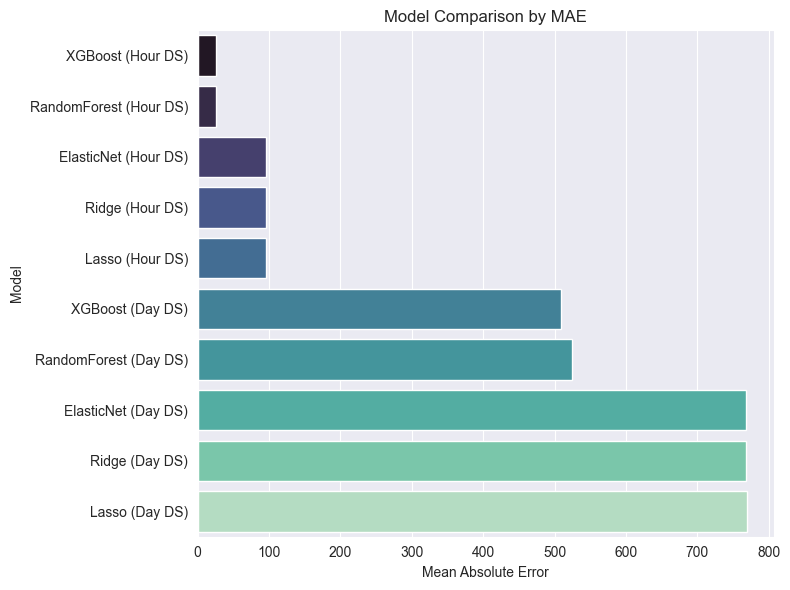

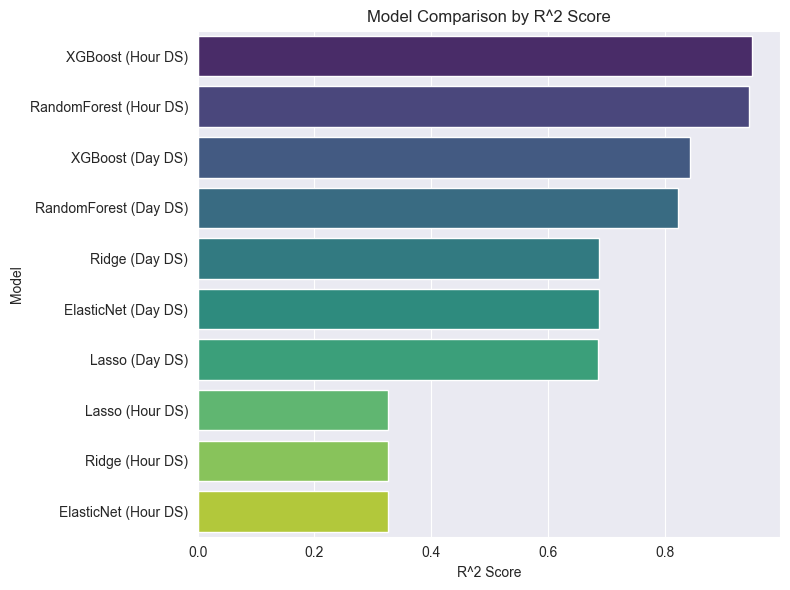

In [139]:
results_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='MAE', y='Model', data=results_df.sort_values('MAE'), ax=ax, palette='mako')
ax.set_title('Model Comparison by MAE')
ax.set_xlabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='R^2', y='Model', data=results_df.sort_values('R^2', ascending=False), ax=ax, palette='viridis')
ax.set_title('Model Comparison by R^2 Score')
ax.set_xlabel("R^2 Score")
plt.tight_layout()
plt.show()
